## **Predicting on single patient data from inferno model in R**

In [2]:
# ======================================================================================================================
# 📁 Setup: Root Directory, Paths, Parallelism, and Data
# ======================================================================================================================

library(inferno)

# Number of cores to use
parallel <- 10

# Root directory for all data
rootdir <- "../data/inferno"

# Directory with trained Inferno models
learntdir <- file.path(rootdir, "combined_new_MT")

# Load metadata
metadata <- read.csv(file.path(learntdir, "metadata.csv"))
print(paste("Loaded metadata with", nrow(metadata), "entries"))

# Load test data
testdata <- read.csv(file.path(rootdir, "calibration_test.csv"))[, metadata$name]
print(paste("Loaded test data with", nrow(testdata), "samples and", ncol(testdata), "features"))


[1] "Loaded metadata with 7 entries"
[1] "Loaded test data with 1459 samples and 7 features"


## **🔥 Single Prediction and Decision Maximizing Medical Utility**

In [3]:
# ----------------------------------------------------------------------------------------------------------------------
# 🔥 Single Prediction and Decision
# ----------------------------------------------------------------------------------------------------------------------

# Define predictands (outcome variables) and predictors (input features)
predictands <- c("LABEL_EFFUSION", "LABEL_ATELECTASIS")
predictors <- setdiff(metadata$name, predictands)

# Define possible outcomes
y <- setNames(expand.grid(0:1, 0:1), as.list(predictands))
outcomenames <- apply(y, 1, function(x) paste0("E", x[1], "_A", x[2]))

# Define utility (or cost-benefit) matrix
ematrix <- matrix(
  c(
    1.00, 0.55, 0.60, 0.40,
    0.90, 1.00, 0.65, 0.75,
    0.90, 0.65, 1.00, 0.75,
    0.80, 0.85, 0.85, 1.00
  ),
  nrow = 4,
  byrow = TRUE
)
colnames(ematrix) <- outcomenames
rownames(ematrix) <- outcomenames

# Patient index to evaluate
patient_idx <- 100

# Extract patient predictors
x_patient <- testdata[patient_idx, predictors, drop = FALSE]

# Extract true labels
true_labels <- testdata[patient_idx, predictands, drop = FALSE]
true_outcome_name <- paste0("E", true_labels[[1]], "_A", true_labels[[2]])

# Predict outcome probabilities
probs <- Pr(
  Y = y,
  X = x_patient,
  learnt = learntdir,
  parallel = parallel
)

# Calculate expected utilities
exputilities <- ematrix %*% probs$values

# Decision function: choose option maximizing expected utility
choosemax <- function(x) {
  sample(rep(which(x == max(x)), 2), 1)
}

# Make decision
decision <- choosemax(exputilities)
# ----------------------------------------------------------------------------------------------------------------------
# 📋 Detailed Report for Single Prediction
# ----------------------------------------------------------------------------------------------------------------------

cat("\n================ Single Prediction Report ================\n")
cat("Patient Index:", patient_idx, "\n\n")

cat("Input predictors for this patient:\n")
print(x_patient)

cat("\nPredicted probabilities for outcomes:\n")
predictions_table <- data.frame(
  Outcome = outcomenames,
  Probability = round(as.numeric(probs$values), 4)
)
print(predictions_table)

cat("\nExpected utilities for each decision:\n")
utility_table <- data.frame(
  Outcome = outcomenames,
  ExpectedUtility = round(as.numeric(exputilities), 4)
)
print(utility_table)

cat("\nTrue labels (ground truth):\n")
print(true_labels)
cat("True outcome name:", true_outcome_name, "\n")

cat("\n✅ Best Decision (Maximizing Expected Utility):", outcomenames[decision], "\n")
cat("==========================================================\n")



================ Single Prediction Report ================
Patient Index: 100 

Input predictors for this patient:
    AGE GENDER VP LOGIT_EFFUSION LOGIT_ATELECTASIS
100  27      M PA       1.243828         -1.856133

Predicted probabilities for outcomes:
  Outcome Probability
1   E0_A0      0.1913
2   E1_A0      0.6626
3   E0_A1      0.0360
4   E1_A1      0.1100

Expected utilities for each decision:
  Outcome ExpectedUtility
1   E0_A0          0.6214
2   E1_A0          0.9407
3   E0_A1          0.7215
4   E1_A1          0.8569

True labels (ground truth):
    LABEL_EFFUSION LABEL_ATELECTASIS
100              1                 1
True outcome name: E1_A1 

✅ Best Decision (Maximizing Expected Utility): E1_A0 


## **📋 Infeno Evaluation on Full Dataset**

- Predictions are made for all patients using the Inferno model.
- Expected utilities are calculated using the clinical utility matrix.
- Optimal decisions are chosen to maximize expected utility for each patient.
- True labels are mapped and checked for consistency.
- Model performance is evaluated based on:
  - **Clinical utility matrix** (reflecting medical priorities).
  - **Bare diagonal matrix** (pure classification accuracy).
  - **Baseline accuracy** (always guessing the most common outcome).
- Results show how the model outperforms naive guessing and how clinical priorities affect evaluation.

In [4]:
# ----------------------------------------------------------------------------------------------------------------------
# 📊 Full Dataset Evaluation Maximizing Medical Utility
# ----------------------------------------------------------------------------------------------------------------------

# Full predictors and true labels
X <- testdata[, predictors, drop = FALSE]
trueY <- testdata[, predictands, drop = FALSE]

# Predict outcome probabilities for full dataset
probs_full <- Pr(
  Y = y,
  X = X,
  learnt = learntdir,
  parallel = parallel,
  quantiles = c(0.055, 0.945),
  nsamples = NULL
)

# Calculate expected utilities for full dataset
exputilities_full <- ematrix %*% probs_full$values

# Make decisions for full dataset
decisions_full <- apply(exputilities_full, 2, choosemax)

# Map true labels to indices
truevalues <- apply(trueY, 1, function(x) (x[1] + 2 * x[2]) + 1)

# Map true labels to outcome names
trueoutcomenames <- apply(trueY, 1, function(x) paste0("E", x[1], "_A", x[2]))

# Calculate baseline and model performance
most_common_value <- which.max(table(truevalues))
baseline_accuracy <- sum(truevalues == most_common_value) / length(truevalues)
avgyield <- mean(ematrix[cbind(decisions_full, truevalues)])

# Create bare identity matrix as utility matrix (perfect classification only)
ematrix_diag <- diag(4)

# Calculate expected utilities and decisions with bare diagonal matrix
exputilities_diag <- ematrix_diag %*% probs_full$values
decisions_diag <- apply(exputilities_diag, 2, choosemax)
avgyield_diag <- mean(ematrix_diag[cbind(decisions_diag, truevalues)])


In [5]:
# ----------------------------------------------------------------------------------------------------------------------
# 📋 Printout of Evaluation Results
# ----------------------------------------------------------------------------------------------------------------------

cat("\nTrue outcome distribution (%):\n")
print(round(table(truevalues) / sum(table(truevalues)) * 100, 2))

cat("\nName consistency check:", all(trueoutcomenames == outcomenames[truevalues]), "\n")

cat("\n🚀 Inferno expected utility (accuracy with clinical utility matrix):", round(avgyield * 100, 1), "%\n")

cat("\n🧪 Expected utility (accuracy with bare diagonal utility matrix):", round(avgyield_diag * 100, 1), "%\n")

cat("\n🎯 Baseline accuracy (predicting most common outcome):", round(baseline_accuracy * 100, 1), "%\n")

cat("=============================================================================\n")


True outcome distribution (%):
truevalues
    1     2     3     4 
46.74 23.51 22.62  7.13 

Name consistency check: TRUE 

🚀 Inferno expected utility (accuracy with clinical utility matrix): 91.8 %

🧪 Expected utility (accuracy with bare diagonal utility matrix): 65.6 %

🎯 Baseline accuracy (predicting most common outcome): 46.7 %


## **🤖 Comparison with Neural Net Decisions at Thresholds 0.5 and 0.27**


- **Threshold 0.5:**  
  - This corresponds to the **usual sigmoid threshold** where a probability ≥ 0.5 is interpreted as a positive prediction.
  - It is a standard classification rule but **does not account for clinical consequences**.

- **Threshold 0.27:**  
  - This is a **lower sigmoid threshold**, equivalent to a logit cutoff at `qlogis(0.27)`.
  - It was chosen to **maximize clinical utility**, aligning better with the clinical utility matrix (ematrix).
  - Lowering the threshold can help **capture more true positives** when missing them is costlier (important in medicine).

- **Purpose of comparison:**  
  - To assess how the standard neural network threshold compares to a clinically optimized threshold, **using the expected utility** based on real clinical priorities rather than pure classification accuracy.

In [7]:
# ----------------------------------------------------------------------------------------------------------------------
# 🤖 Comparison with Neural Net Decisions at Thresholds 0.5 and 0.27
# ----------------------------------------------------------------------------------------------------------------------

# --- Neural Net decisions at sigmoid threshold 0.5 ---
responsesNN_05 <- apply(
  testdata[, c("LOGIT_EFFUSION", "LOGIT_ATELECTASIS")],
  1,
  function(x) 1 * (x >= 0)
)

decisionsNN_05 <- apply(responsesNN_05, 2, function(x) {
  (x[1] + 2 * x[2]) + 1
})

responsenames_05 <- apply(responsesNN_05, 2, function(x) paste0("E", x[1], "_A", x[2]))

cat("\nNN decision naming check (threshold 0.5):",
    all(responsenames_05 == outcomenames[decisionsNN_05]), "\n")

avgyieldNN_05 <- mean(ematrix[cbind(decisionsNN_05, truevalues)])
cat("NN expected utility (accuracy, threshold 0.5):",
    round(avgyieldNN_05 * 100, 1), "%\n")

# --- Neural Net decisions at sigmoid threshold 0.27 ---
logit_threshold_027 <- qlogis(0.27)

responsesNN_027 <- apply(
  testdata[, c("LOGIT_EFFUSION", "LOGIT_ATELECTASIS")],
  1,
  function(x) 1 * (x >= logit_threshold_027)
)

decisionsNN_027 <- apply(responsesNN_027, 2, function(x) {
  (x[1] + 2 * x[2]) + 1
})

responsenames_027 <- apply(responsesNN_027, 2, function(x) paste0("E", x[1], "_A", x[2]))

cat("\nNN decision naming check (threshold 0.27):",
    all(responsenames_027 == outcomenames[decisionsNN_027]), "\n")

avgyieldNN_027 <- mean(ematrix[cbind(decisionsNN_027, truevalues)])
cat("NN expected utility (accuracy, threshold 0.27):",
    round(avgyieldNN_027 * 100, 1), "%\n")

cat("==========================================================\n")



NN decision naming check (threshold 0.5): TRUE 
NN expected utility (accuracy, threshold 0.5): 89.5 %

NN decision naming check (threshold 0.27): TRUE 
NN expected utility (accuracy, threshold 0.27): 91.4 %


# 📊 Calibration Curves for Neural Net Outputs vs Inferred Probabilities

- For each condition (Effusion, Atelectasis), two plots are shown sequentially:
  - **Sigmoid output calibration curve:**  
    CNN predicted probability (after sigmoid) vs Bayesian inferred true probability; perfect calibration follows the diagonal.
  - **Logit output view:**  
    CNN raw logit scores vs Bayesian inferred probability to visualize score-to-probability mapping.
- **Threshold at 0.27 is highlighted:**  
  - This is the **optimal fixed threshold for CNN outputs** to maximize expected clinical utility across the dataset.
  - **If using CNN alone:**  
    - A hard cutoff at 0.27 is applied: patients with CNN sigmoid output > 0.27 are classified positive.
    - **Problem:** This approach assumes every patient's CNN score is perfectly calibrated, ignoring case-by-case uncertainty.
    - A patient close to the threshold may have very different real risk depending on hidden factors, leading to misclassifications.
  - **If using Inferno Bayesian probabilities:**  
    - We obtain a calibrated probability for each patient individually, incorporating uncertainty.
    - Decisions are personalized and better aligned with maximizing clinical utility for each patient.
- **Plot mechanics:**  
  - X-axis: CNN predicted probability (`plogis(logit)`).
  - Y-axis: True corrected probability (`Pr()` output).
- **Goal:**  
  To evaluate how well CNN output confidence matches reality, and to justify Bayesian recalibration for patient-specific decision-making.

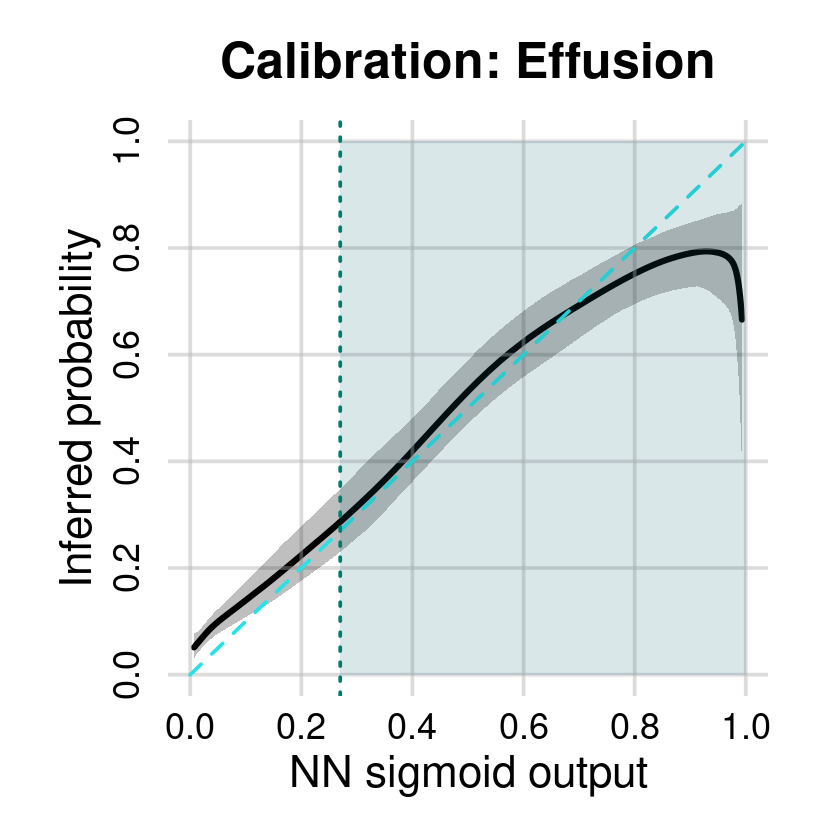

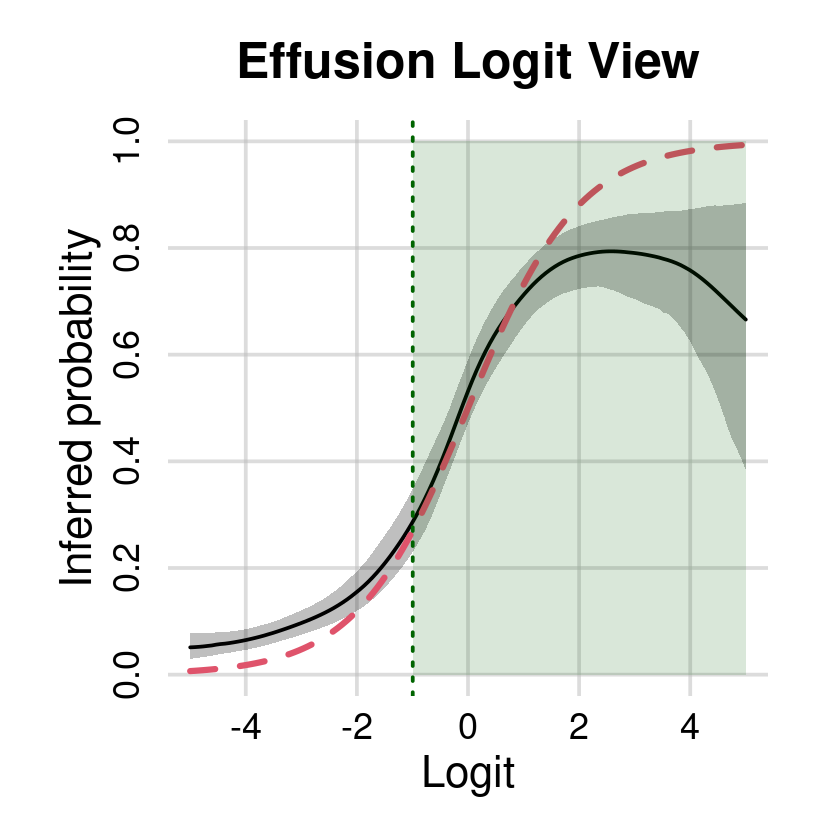

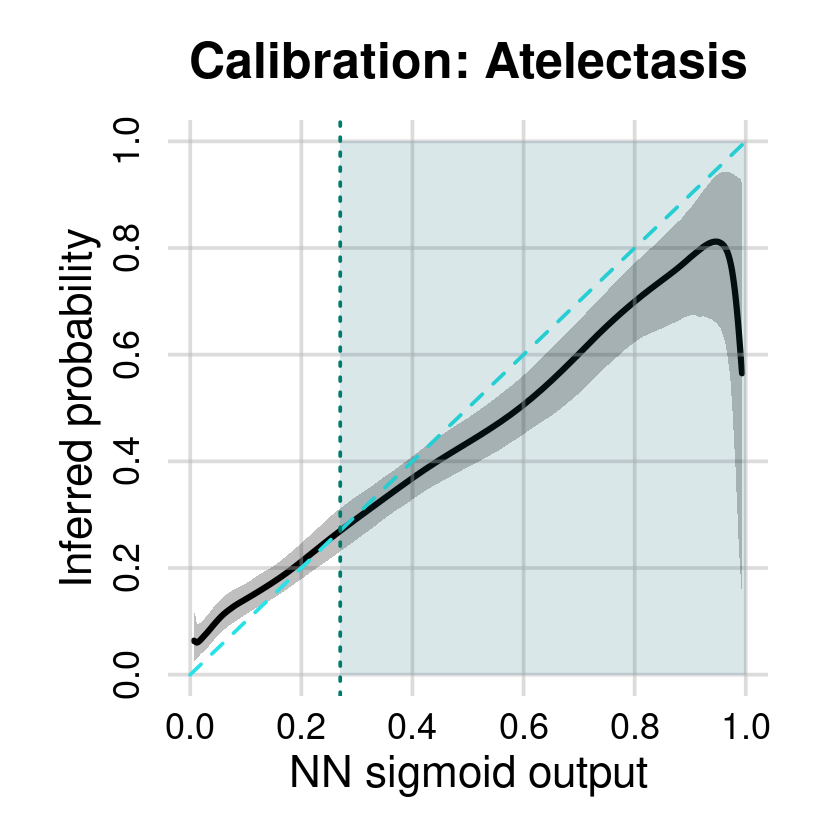

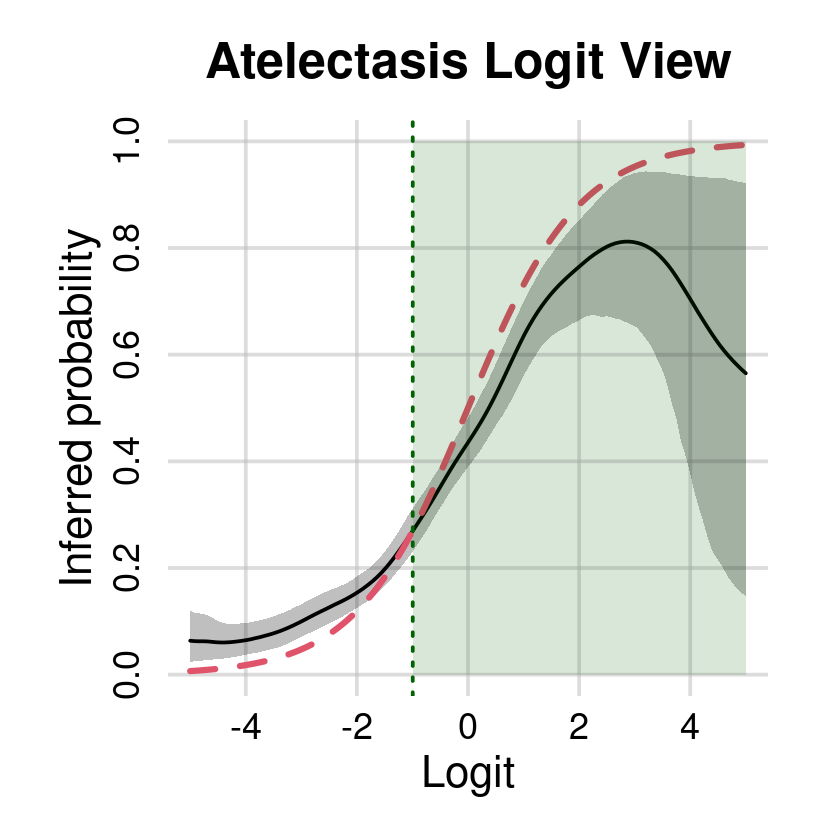

In [18]:
# ----------------------------------------------------------------------------------------------------------------------
# 📊 Calibration Curves for Neural Net Outputs vs Inferred Probabilities
# ----------------------------------------------------------------------------------------------------------------------

# Helper function to plot calibration curves for one label
plot_calibration <- function(outNN, probNN, label_main) {
  par(mar = c(6, 7, 5, 3), cex.axis = 1.8, cex.lab = 2.2, cex.main = 2.5, lwd = 3)

  # Sigmoid output vs inferred probability
  flexiplot(
    x = plogis(outNN[, 1]),
    y = c(probNN$values),
    xlab = "NN sigmoid output", ylab = "Inferred probability",
    ylim = 0:1, xlim = 0:1, lwd = 5, main = paste("Calibration:", label_main)
  )
  plotquantiles(x = plogis(outNN[, 1]), y = probNN$quantiles[1, , ], add = TRUE)
  flexiplot(x = 0:1, y = 0:1, lty = 2, lwd = 3, col = 5, add = TRUE)
  polygon(x = c(0.27, 1, 1, 0.27), y = c(0, 0, 1, 1), col = adjustcolor("#0f606b", alpha.f = 0.15), border = NA)
  abline(v = 0.27, col = "#007c6c", lty = 3, lwd = 3)

  # Logit vs inferred probability
  plot(probNN, xlab = "Logit", ylab = "Inferred probability", ylim = 0:1, legend = FALSE, main = paste(label_main, "Logit View"))
  flexiplot(x = outNN, y = plogis(outNN[, 1]), lty = 2, col = 2, lwd = 5, add = TRUE)
  polygon(x = c(qlogis(0.27), 5, 5, qlogis(0.27)), y = c(0, 0, 1, 1), col = adjustcolor("darkgreen", alpha.f = 0.15), border = NA)
  abline(v = qlogis(0.27), col = "darkgreen", lty = 3, lwd = 3)
}

# Effusion Calibration
outNN_effusion <- data.frame(LOGIT_EFFUSION = seq(-5, 5, length.out = 129))
probNN_effusion <- Pr(
  Y = data.frame(LABEL_EFFUSION = 1),
  X = outNN_effusion,
  learnt = learntdir,
  parallel = parallel,
  quantiles = c(0.055, 0.945),
  nsamples = NULL
)
plot_calibration(outNN_effusion, probNN_effusion, "Effusion")

# Atelectasis Calibration
outNN_atelectasis <- data.frame(LOGIT_ATELECTASIS = seq(-5, 5, length.out = 129))
probNN_atelectasis <- Pr(
  Y = data.frame(LABEL_ATELECTASIS = 1),
  X = outNN_atelectasis,
  learnt = learntdir,
  parallel = parallel,
  quantiles = c(0.055, 0.945),
  nsamples = NULL
)
plot_calibration(outNN_atelectasis, probNN_atelectasis, "Atelectasis")
